## Data Science Assignment

 Cleaning and preprocessing the `T2_A24_census3.xlsx` dataset for further analysis. This process includes handling missing values.  
 Missing values are addressed by reassigning **intelligent** or **statistically derived** values, enabling accurate statistical and numerical analysis.  
 The goal is to provide insights for the development of the city, based on the requirements of the assignment.  
 We will unpack these missing and inconsistent values **step by step**, for clarity.
 


## Importing Relevant Liberary for the preprocessing and analysis

In [2]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pprint import pprint

## Data Preprocessing and Cleaninng Stage

In [3]:
df = pd.read_excel('./T2_A24_census3.xlsx')          # reading the xlsx data set

In [4]:
df.head()

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Brass Haven,Angela,Jenkins,39,Head,Married,Female,Camera operator,NaN,Christian
1,1,Brass Haven,George,Jenkins,39,Husband,Married,Male,Secondary school teacher,NaN,No Religion
2,1,Brass Haven,Jessica,Jenkins,9,Daughter,NaN,Female,Student,NaN,Christian
3,2,Brass Haven,Declan,Robinson,29,Head,Married,Male,Accounting technician,NaN,No Religion
4,2,Brass Haven,Carolyn,Robinson,25,Wife,Married,Female,"Development worker, international aid",NaN,No Religion


In [5]:
df.isna().sum()          #checking columns with missing values and its sum  (house number = 0 missing values, surname = 11 missing values) and so on

House Number                         0
Street                               0
First Name                           0
Surname                             11
Age                                  0
Relationship to Head of House      731
Marital Status                    2368
Gender                               0
Occupation                           0
Infirmity                        10246
Religion                          1298
dtype: int64

In [6]:
Missing_valuess =  df.isna().sum()  

percentage = (Missing_valuess/len(df))*100

print(percentage.round(2))

House Number                      0.00
Street                            0.00
First Name                        0.00
Surname                           0.11
Age                               0.00
Relationship to Head of House     7.06
Marital Status                   22.87
Gender                            0.00
Occupation                        0.00
Infirmity                        98.95
Religion                         12.54
dtype: float64


In [7]:
df.dtypes      # take a look at the data types to verify they are of valid data types

House Number                      int64
Street                           object
First Name                       object
Surname                          object
Age                               int64
Relationship to Head of House    object
Marital Status                   object
Gender                           object
Occupation                       object
Infirmity                        object
Religion                         object
dtype: object

In [8]:
# checking for correlation between Age and House number
# since the  correlation is less than 0.5
# implies  the data set is okay
df[['Age', 'House Number']].corr()  

,Age,House Number
Age,1.000000,0.027307
House Number,0.027307,1.000000


### Unpacking and Filling Missing Values in Surname

##### We can infer missing `Surname` values by using information from other household members, such as `House Number`, `Street`, and `Relationship to Head of House`.  

##### This data imputation can be efficiently achieved through **vectorized operations**.


In [9]:
df = df.reset_index(drop=True)

In [10]:
# Clean column names
df.columns = df.columns.str.strip()

# Extract head surnames
head_surnames = df.loc[df['Relationship to Head of House'] == 'Head', ['House Number', 'Street', 'Surname']]
head_surnames = head_surnames.set_index(['House Number', 'Street'])['Surname']

# Only fill missing surnames
df['Surname'] = df.set_index(['House Number', 'Street'])['Surname'].fillna(head_surnames).reset_index(level=[0,1])['Surname']


In [11]:
df.isna().sum()

House Number                         0
Street                               0
First Name                           0
Surname                              0
Age                                  0
Relationship to Head of House      731
Marital Status                    2368
Gender                               0
Occupation                           0
Infirmity                        10246
Religion                          1298
dtype: int64

In [12]:
df.loc[2049, ['First Name','Surname', 'Relationship to Head of House']] # sampling one data to verify its okay and cor

First Name                            Paula
Surname                          Brown-Todd
Relationship to Head of House          Wife
Name: 2049, dtype: object

### Filling Missing Values for Marital Status Using Age

 Before filling missing values in the `Marital Status` column, we need to explore the data to check whether all missing values correspond to individuals under 18 years of age.  

If all missing values are for individuals below 18, we can safely fill them with `"Single"`.  

If not, we can fill missing values for individuals under 18 with `"Single"` and fill the remaining missing values with the **mode** of the column, or infer values using other relevant columns. The goal is to choose the approach that is **statistically sound** or **logically most appropriate**.


In [13]:
# Show only rows where 'Marital Status' is missing (NaN)
df_missing = df[df['Marital Status'].isna()][['Age', 'Marital Status']]

# Check if all ages in missing 'Marital Status' are below 18
all_below_18 = (df_missing['Age'] < 18).all()

print(all_below_18)

# Display the result of where 'Marital Status' is missing (NaN) along side their Age respectively 
# print(df_missing)


True


In [14]:
#fill blank rows with 'Single', since all blank marital rows is below 18

df['Marital Status'] = df['Marital Status'].fillna('Single')   
print('Successfuly filled all missing values for Marital Status as Single')

Successfuly filled all missing values for Marital Status as Single


### Filling Missing Values for Infirmity

 The `Infirmity` column contains a very large number of missing values. Handling these missing values requires either additional information from the data source or application of domain knowledge.

Infirmity refers to a serious or life-threatening illness. Since over 80% of the dataset has missing values for this column, it is reasonable to assume that citizens with missing values do not have any infirmity.

Therefore, filling the missing values with `"None"` is the most logical approach, rather than using `"Unknown"`.


In [15]:
# filling all missing values of infirmity with None

df['Infirmity'] = df['Infirmity'].fillna('None')

print('Successfuly filled all missing values for Infirmity as None')

Successfuly filled all missing values for Infirmity as None


### Filling Missing Values for *Relationship to Head of House*

Before imputing the missing values, we first verify the structure of each household to ensure that every household already has a Head assigned. This step is crucial to avoid accidentally assigning more than one Head to the same household.

Since all households with missing values already have an assigned Head, we can now infer the missing relationships using logical comparisons based on `Marital Status`, `Age`, and `Gender`.

These attributes provide meaningful signals that help categorize household members more accurately, while maintaining consistency and preventing contradictory assignments.


In [16]:

# One-liner to see missing relationships + household Head info
missing_head = (
    df.loc[df['Relationship to Head of House'].isna()]
      .merge(
          df.groupby(['House Number', 'Street'])['Relationship to Head of House']
            .apply(lambda x: (x == 'Head').any())
            .rename('Has_Head'),
          on=['House Number', 'Street']
      )
      [['House Number', 'Street', 'First Name', 'Surname', 'Has_Head']]
)

 # Check if all Has_Head values are True
all_have_head = missing_head['Has_Head'].all()
print(all_have_head)


True


##### Creating New Columns for Comparison

We will create new columns to help us make comparisons and draw insights, **while keeping the original dataset unchanged**.  

These new columns allow us to perform **logical checks and vectorized operations** more efficiently, without affecting the original `Relationship to Head of House` column.  

This approach ensures that we **preserve the original data** and can easily revert changes if needed.



In [17]:

# make a new df column to hold the filtered data other than modifying it directly
df['RTHH_filled'] = df['Relationship to Head of House']

# filtering for Married adults, male and female inclusive with same surname as heads
df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Marital Status'] == 'Married') & (df['Age'] >=18) & (df['Gender'] == 'Male'),
    'Husband',
    df['RTHH_filled']
)
df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Marital Status'] == 'Married') & (df['Age'] >=18) & (df['Gender'] == 'Female'),
    'Wife',
    df['RTHH_filled']
)

# for Children under 18 with same surname as head
# First, map each household's Head surname
head_surnames = df[df['Relationship to Head of House'] == 'Head'].set_index(['House Number','Street'])['Surname']

# Map Head surname to everyone in the same household
df['Head_Surname'] = df.set_index(['House Number','Street']).index.map(head_surnames)

df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Age'] < 18) & (df['Surname'] == df['Head_Surname']) & (df['Gender'] == 'Male'),
    'Son',
    df['RTHH_filled']
)



df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Age'] < 18) & (df['Surname'] == df['Head_Surname']) & (df['Gender'] == 'Female'),
    'Daughter',
    df['RTHH_filled']
)

#for Children under 18 with different heads surname
df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Age'] < 18) & (df['Surname'] != df['Head_Surname']) & (df['Gender'] == 'Female'),
    'Nice',
    df['RTHH_filled']
)

df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Age'] < 18) & (df['Surname'] != df['Head_Surname']) & (df['Gender'] == 'Male'),
    'Nephew',
    df['RTHH_filled']
)

# for Adults greater than 18 with same heads surname
df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Age'] >=18) & (df['Surname'] == df['Head_Surname']),
    'Siblings',
    df['RTHH_filled']
)

# for Adults with different heads surname
df['RTHH_filled'] = np.where(
    df['RTHH_filled'].isna() & (df['Age'] >= 18) & (df['Surname'] != df['Head_Surname']),
    'Others',
    df['RTHH_filled']
)

In [18]:
df['Relationship to Head of House'] = df['RTHH_filled']     # Replacing our cleaned column with the original after verifying its okay

df.drop(columns=['Head_Surname', 'RTHH_filled'], inplace=True)    # deleting  the new columns that helped us in filters and cleaning the data

In [19]:
df.isna().sum()     # sampling to see the impact of the cleaning

House Number                        0
Street                              0
First Name                          0
Surname                             0
Age                                 0
Relationship to Head of House       0
Marital Status                      0
Gender                              0
Occupation                          0
Infirmity                           0
Religion                         1298
dtype: int64

In [20]:
Religion =  pd.crosstab(df['Religion'], columns= df['Gender'], normalize = True)*100     # checking the percentage of religion across gender

print(Religion.round(2))       # Round up the values to 2dp

Gender             Female   Male
Religion                        
Bahai                0.03   0.03
Catholic             0.01   0.00
Christian           28.06  22.87
Church of England    0.02   0.02
Dark Brotherhood     0.01   0.00
Greek                0.01   0.01
Hindu                0.53   0.42
Humanist             0.01   0.01
Muslim               1.14   0.76
No Religion         22.78  22.70
Oasis                0.00   0.01
Sikh                 0.31   0.25


In [65]:
df['Gender'].value_counts()    # checking which Gender has more population

Gender
Female    5426
Male      4929
Name: count, dtype: int64

In [21]:
pd.crosstab(
    index = [df['Religion'],df['Gender']],columns = df['Marital Status'], normalize = 'index'
           )*100

Marital Status             Divorced     Married      Single     Widowed
Religion          Gender                                               
Bahai             Female   0.000000   33.333333   66.666667    0.000000
                  Male     0.000000    0.000000  100.000000    0.000000
Catholic          Female   0.000000    0.000000    0.000000  100.000000
Christian         Female  12.750885   29.830775   50.885478    6.532861
                  Male     9.753742   31.192661   53.211009    5.842588
Church of England Female   0.000000  100.000000    0.000000    0.000000
                  Male     0.000000   50.000000   50.000000    0.000000
Dark Brotherhood  Female   0.000000    0.000000  100.000000    0.000000
Greek             Female   0.000000    0.000000  100.000000    0.000000
                  Male     0.000000    0.000000  100.000000    0.000000
Hindu             Female  25.000000   35.416667   37.500000    2.083333
                  Male    21.052632   31.578947   47.368421    0.000000
Humanist          Female   0.000000    0.000000  100.000000    0.000000
                  Male     0.000000    0.000000  100.000000    0.000000
Muslim            Female  10.679612   31.067961   53.398058    4.854369
                  Male    10.144928   36.231884   52.173913    1.449275
No Religion       Female  12.893844   28.405235   54.968492    3.732429
                  Male     7.101167   34.095331   56.468872    2.334630
Oasis             Male     0.000000  100.000000    0.000000    0.000000
Sikh              Female  17.857143   39.285714   28.571429   14.285714
                  Male     4.347826   34.782609   56.521739    4.347826

### Filling the Religion Column

We will fill the missing values in the **Religion** column using **machine learning**.  

Religion is a personal attribute, so being careful and use features that are **unbiased**.  
In this dataset, we will use:

- Age  
- Gender  
- Marital Status  

These features should give a fair prediction.  
We will use **RandomForestClassifier** to predict the missing values.


#### Extracting the Liberary for the machine learning

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:

# Spliting the data into train/test

df_train = df[df['Religion'].notna()].copy()      #creating a temporal copy of the fill
df_missing = df[df['Religion'].isna()].copy()

# Creating features to use as x cordinate
features = ['Age', 'Gender', 'Marital Status']

X_train = df_train[features]
y_train = df_train['Religion']   # using Religion as the label the model will predict

X_predict = df_missing[features]

# Build preprocessing transformer for ML
# Transforming thing data using one hot enconder 
# to transform caategorical data into format readible by the machine

categorical_cols = ['Gender', 'Marital Status']
numeric_cols = ['Age']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


# Machine Learning Model

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    class_weight="balanced"
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# Training the model

pipeline.fit(X_train, y_train)

# Predict missing Religion values

predictions = pipeline.predict(X_predict)

# Assign predictions back to df
df.loc[df['Religion'].isna(), 'Religion'] = predictions



In [24]:
predictions

array(['Christian', 'Christian', 'No Religion', ..., 'No Religion',
       'No Religion', 'No Religion'], shape=(1298,), dtype=object)

In [25]:
df.isna().sum()

House Number                     0
Street                           0
First Name                       0
Surname                          0
Age                              0
Relationship to Head of House    0
Marital Status                   0
Gender                           0
Occupation                       0
Infirmity                        0
Religion                         0
dtype: int64

In [26]:
df['Religion'].value_counts()

Religion
No Religion          4911
Christian            4745
Muslim                323
Hindu                 116
Sikh                  116
Bahai                 100
Church of England      36
Greek                   3
Humanist                2
Catholic                1
Oasis                   1
Dark Brotherhood        1
Name: count, dtype: int64

### Cleaning Abnormal and Inconsistent Data

First, we need to check for **abnormal or inconsistent values** in the dataset, cross referenceit with:
- Age  
- Marital Status  
- Relationship to Head of House  

Using **conditional logic**, we create series of  **boolean expressions** then we sum them to see how many inconsistencies exist.



##### Checking for Ages less that 18 and has some marital related status

In [27]:
#sampling a date to see the status

df.loc[[4629], ['First Name', 'Surname', 'Age', 'Relationship to Head of House', 'Marital Status']]  

,First Name,Surname,Age,Relationship to Head of House,Marital Status
4629,Kate,Alexander,11,Head,Married


In [28]:
# create a new variable to hold the conditional logic

Ages_under_18_not_single = (df['Age']<18) & (df['Marital Status'] != 'Single')
Count_ages_under_18_not_single = Ages_under_18_not_single.sum()    # sum the count of True values

print(f'Numbeer of row with Ages < 18 and not Single: {Count_ages_under_18_not_single}')

Numbeer of row with Ages < 18 and not Single: 36


##### Checking for Ages less than 19 and name Head

In [29]:
# create a new variable to hold the conditional logic
Ages_under_19_and_head = (df['Age']<19) & (df['Relationship to Head of House'] == 'Head')
Count_ages_under_19_and_head = Ages_under_19_and_head.sum()        # sum the count of True values

print(f'Number of row with Ages < 19 named Head of House: {Count_ages_under_19_and_head}')

Number of row with Ages < 19 named Head of House: 31


##### Since our data contain Age less than 18 married and less than 19 considered as head we have to unpack and reassign respectively

In [30]:

# for Ages below 18 and classed a married, divoced, window 
# cleaning and setting them up to single as it is illegal for Ages below 18 to be married an on
df['Marital Status'] = np.where(
    (df['Marital Status'] != 'Single') & (df['Age'] < 18), 'Single', df['Marital Status'] 
)

print('successfuly cleaned and updated abnormal data')

successfuly cleaned and updated abnormal data


In [31]:
df.columns = df.columns.str.strip()

df['Relation to Head of House'] = df['Relationship to Head of House']

df.loc[(df['Relationship to Head of House'] == 'Head') & (df['Age'] < 19),
       'Relation to Head of House'] = df.loc[df['Age'] < 19, 'Gender'].map({
           'Male': 'Son',
           'Female': 'Daughter'
       })
df.loc[(df['Relationship to Head of House'] == 'Head') & (df['Age'] < 4),
       'Relation to Head of House'] = df.loc[df['Age'] < 4, 'Gender'].map({
           'Male': 'Grandson',
           'Female': 'Granddaughter'
       })

print('Successfuly cleaned less than 19, for Male and Female with same Surnname, and not same Surname')

Successfuly cleaned less than 19, for Male and Female with same Surnname, and not same Surname


In [32]:
df.loc[[4629], ['First Name', 'Surname', 'Age', 'Relationship to Head of House', 'Marital Status', 'Gender']] 

,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender
4629,Kate,Alexander,11,Head,Single,Female


The Abnornal Data persist after imputing the new values
we had to sample the row to see the data strructure to know why the change is not effected

In [33]:
df.loc[4629].to_dict()  # to sample the real data structure of this row 


{'House Number': 8,
 'Street': 'Wales Avenue',
 'First Name': 'Kate',
 'Surname': 'Alexander',
 'Age': 11,
 'Relationship to Head of House': 'Head',
 'Marital Status': 'Single',
 'Gender': 'Female',
 'Occupation': 'Student',
 'Infirmity': 'None',
 'Religion': 'Christian',
 'Relation to Head of House': 'Daughter'}

In [34]:
# notice we had two columns with same name
# Replacing the original data frame with the new on

df['Relationship to Head of House'] = df['Relation to Head of House']


In [35]:
df.loc[[4629], ['First Name', 'Surname', 'Age', 'Relationship to Head of House', 'Marital Status', 'Gender']] 


,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender
4629,Kate,Alexander,11,Daughter,Single,Female


## Data Analysis and Visualization Stage

#### Analyzing and ploting visuals for Age Pyramid

In [36]:
Age_series = df['Age']

print(Age_series.min())   #accessing the minimun value
print(Age_series.max())      # accesing the maximum value

0
110


##### Creating age group between 0 and 111, with intervals of 5

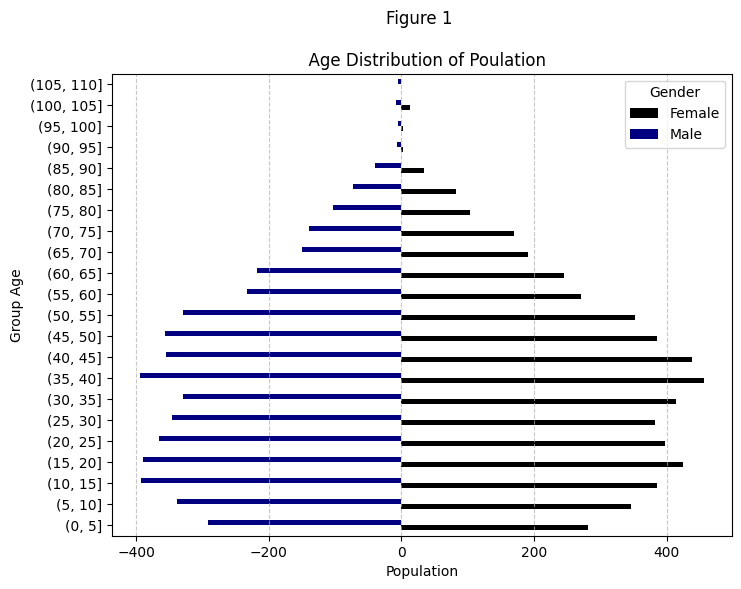

In [37]:
age_bins = list(range(0,111,5))    # Creates the range and assign it to the variable
df['Group Age'] = pd.cut(df['Age'], bins = age_bins)    # create a new column to hold distributed age and assign each person to a group

# group the new column and gender
# Also count the number of males and females in the group
Age_pyramid = df.groupby(['Group Age', 'Gender'], observed=True).size().unstack(fill_value = 0)

Age_pyramid['Male'] = -Age_pyramid['Male']     # assign a negative value to male for female to become the positive valyue

#plot the Age pyramid graphs
Age_pyramid.plot(kind='barh', stacked = False, figsize=(8,6), color = ['black', 'navy'])

# Assign labels to each axis
plt.xlabel('Population')   # represent the vertical axis, this is because of the bar flip from bar to barh, the axis also flips
plt.ylabel('Group Age')     # represnets the horizontal axis
plt.title('Figure 1 \n\n  Age Distribution of Poulation')      # the title of the plot
plt.grid(axis = 'x', linestyle='--', alpha=0.7)    # plots the doted grid and the show the transpency  
plt.savefig('Age_Distribution_by_Pyramid.png', dpi = 300, bbox_inches = 'tight')   # save quality plot locally
plt.show()     #show the plot on the terminal

In [39]:
df['Occupation'].value_counts()

Occupation
Student                           2007
University Student                 682
Unemployed                         677
Child                              553
Editor, magazine features           21
                                  ... 
Retired Sales professional, IT       1
Retired Soil scientist               1
Retired Probation officer            1
Retired Cytogeneticist               1
Retired Comptroller                  1
Name: count, Length: 1139, dtype: int64

#### Ploting Visuals on Unemployment trend by Age distribution

After careful examination of the occupation there are sommany cavets that can overestimate the Unemployment status
if we include students, and underestimate unemployment stauts negelect student potenialy dont going to have jobs after graduation

In [40]:
print(Age_pyramid.columns)

Index(['Female', 'Male'], dtype='object', name='Gender')


In [76]:
def employment_status(Occupation):   # create a funnction to hold the argument occupation
    if 'Unemployed' in Occupation:
        return 'Unemployed'
    elif 'Student' in Occupation:
        return 'In Education'
    elif 'University Student' in Occupation:
        return 'In Education'
    elif 'PhD Student' in Occupation:
        return 'In Education'
    else:
        return 'Employed & Retired'

df['Employment Status'] = df['Occupation'].apply(employment_status)   # ceate a new column and append the new filtered outcome


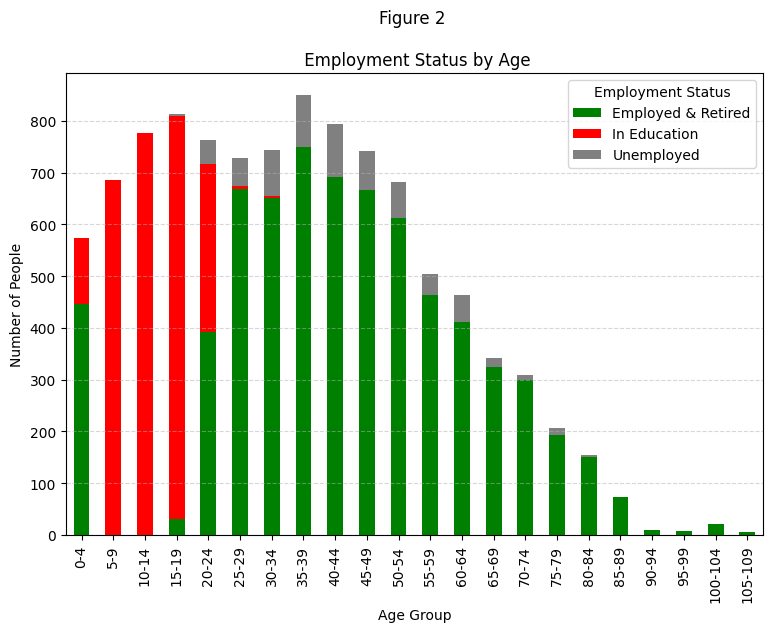

In [77]:
age_bins = list(range(0, 111, 5))
age_labels = [f"{i}-{i+4}" for i in range(0, 110, 5)]
df['Group Age'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

Unemployment_trend = df.groupby(['Group Age', 'Employment Status'], observed = True).size().unstack(fill_value=0)

Unemployment_trend.plot(kind='bar', stacked=True, figsize=(9,6), color=['green','red','gray'])

plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.title('Figure 2 \n\n Employment Status by Age')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('Unemployment_Trend_By_Age.png', dpi = 300)
plt.show()


### Using A volin chat to plot the distribution of Age by Innfirmity
This is to verify the distrubistion of population with infirmity as  older population and prone to infirmity, 
this distribution helps us indentify what future development best suties this population.
The dotted line in the chart shows the density of the ages usin the aage median

C:\Users\HP\AppData\Local\Temp\ipykernel_8556\3731766327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


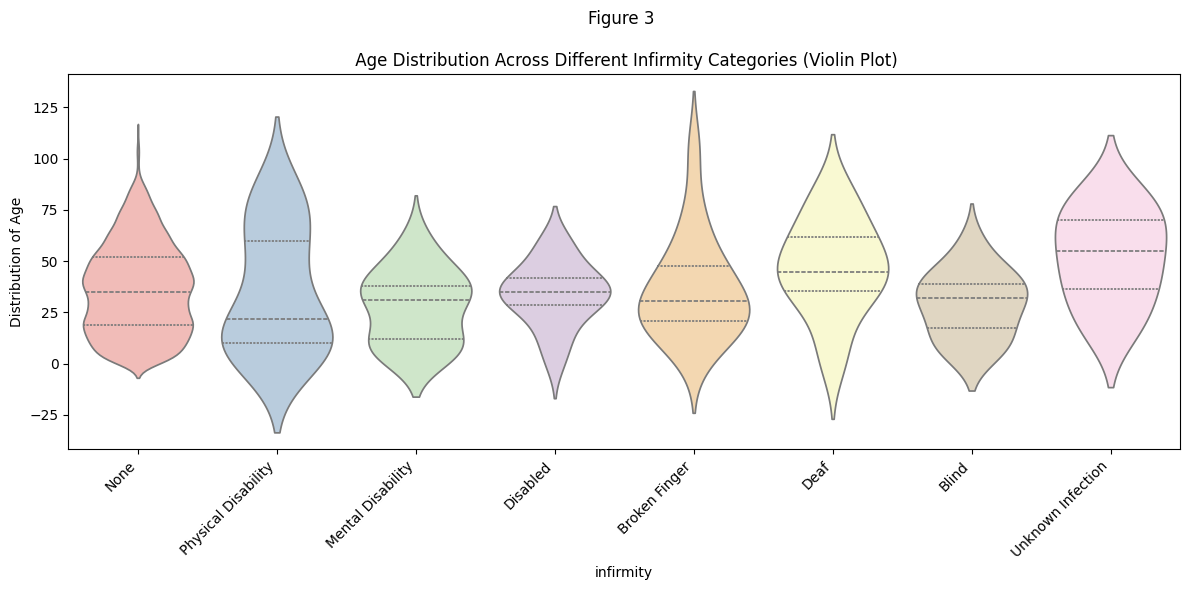

In [43]:
# using Violin Plot (Shows density better) 
# A Violin Plot is often preferred as it shows the full probability density
# of the age distribution, not just the quartiles.

plt.figure(figsize=(12, 6))
sns.violinplot(
    x=df['Infirmity'],  #assigning the x and y variable to the chart
    y=df['Age'],
    palette='Pastel1',
    inner='quartile' # Shows the median and quartiles inside the violin
)
plt.xlabel("infirmity")  # text on the x axias
plt.ylabel("Distribution of Age")   #text oin the y axias
plt.title("Figure 3 \n\n Age Distribution Across Different Infirmity Categories (Violin Plot)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('age_distribution_by_infirmity_violinplot.png')
plt.show()

##### Using Seaborn to plot unemployment percentage rate by Age

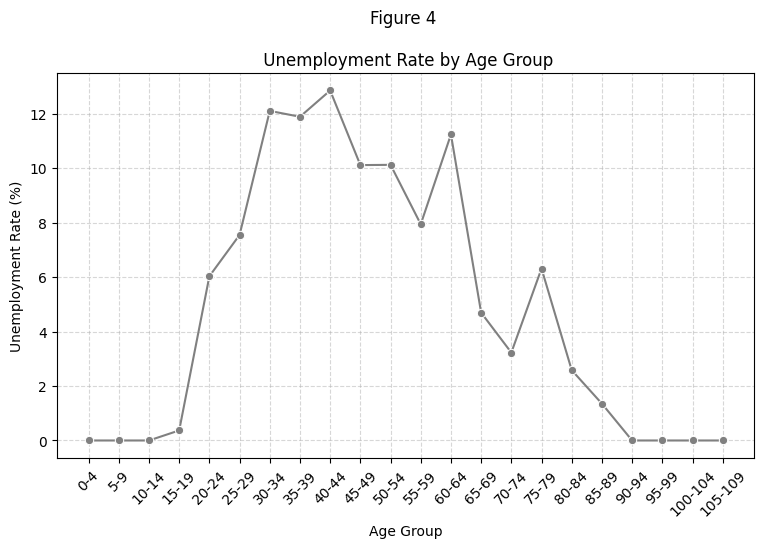

In [44]:
# Calculate unemployment rate per age group
unemployment_rate = df.groupby(['Group Age','Employment Status'], observed = True).size().unstack(fill_value=0)
unemployment_rate['Total'] = unemployment_rate.sum(axis=1)
unemployment_rate['Unemployment Rate (%)'] = (unemployment_rate['Unemployed'] / unemployment_rate['Total']) * 100

# Plot with Seaborn
plt.figure(figsize=(9,5))
sns.lineplot(
    data=unemployment_rate,
    x =unemployment_rate.index,
    y ='Unemployment Rate (%)',
    marker ='o',
    color ='gray'
)

# Assigning labels
plt.xticks(rotation=45)
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Age Group')
plt.title('Figure 4 \n\n Unemployment Rate by Age Group')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('Unemployment_Rate_by_Age_Group', dpi = 300)
plt.show()


#### Ploting the Religious progress with stacked bar chart to indentiy if its growing or shrinking

C:\Users\HP\AppData\Local\Temp\ipykernel_8556\1043488723.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  religion_counts['Percent'] = religion_counts.groupby('Group Age')['Count'].transform(lambda x: 100*x/x.sum())


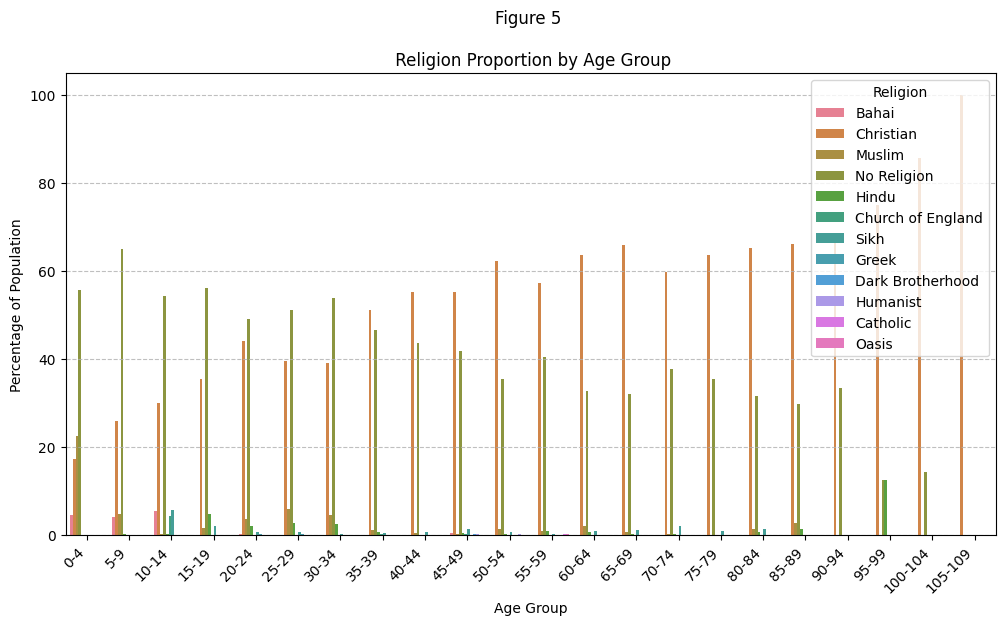

In [45]:

# Count number of people in each Group Age and Religion
religion_counts = df.groupby(['Group Age','Religion'], observed = True).size().reset_index(name='Count')

# Add a percentage column per Group Age
religion_counts['Percent'] = religion_counts.groupby('Group Age')['Count'].transform(lambda x: 100*x/x.sum())

## now plotting
plt.figure(figsize=(12,6))
sns.barplot(
    data=religion_counts,
    x='Group Age',
    y='Percent',
    hue='Religion'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage of Population')
plt.xlabel('Age Group')
plt.title('Figure 5 \n\n Religion Proportion by Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.savefig('Religion_Proportion_by_Age Group.png', dpi = 300)
plt.show()


#### Using line plot to indentify the trend 

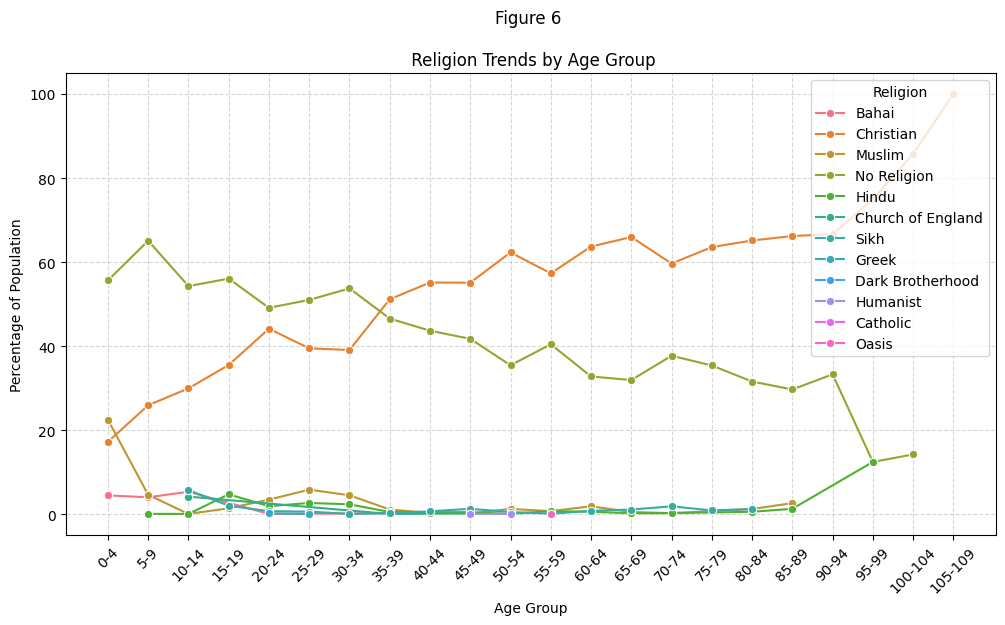

In [79]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data = religion_counts,
    x ='Group Age',
    y ='Percent',
    hue ='Religion',
    marker ='o'
)
plt.xticks(rotation=45)
plt.ylabel('Percentage of Population')
plt.xlabel('Age Group')
plt.title('Figure 6 \n\n Religion Trends by Age Group')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('Religion_Trends_by_Age_Group.png', dpi = 300)
plt.show()


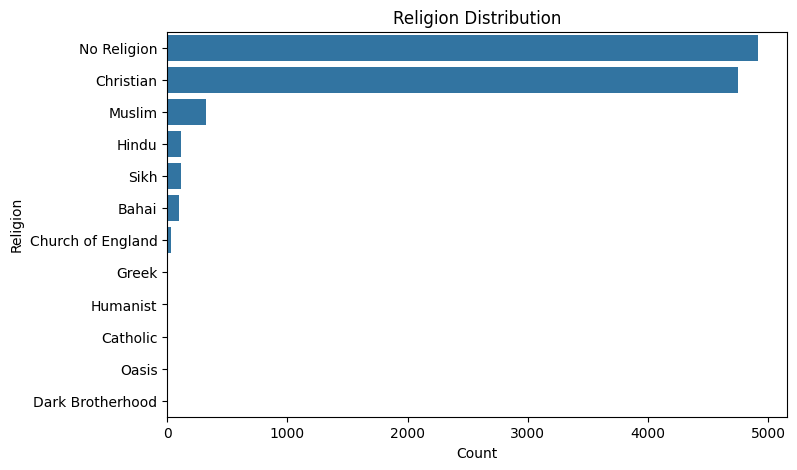

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(y='Religion', data=df, order=df['Religion'].value_counts().index)
plt.title('Religion Distribution')
plt.xlabel('Count')
plt.ylabel('Religion')
plt.savefig('Religion_Distribution.png', dpi = 300)
plt.show()


### Using a Doughnt Chart to Display Marital Status Relationship

In [47]:
# Count each marital status
## show the percentage to deteermine if pie chart will be siotable
df['Marital Status'].value_counts(normalize = True)*100

Marital Status
Single      59.246741
Married     27.049734
Divorced     9.589570
Widowed      4.113955
Name: proportion, dtype: float64

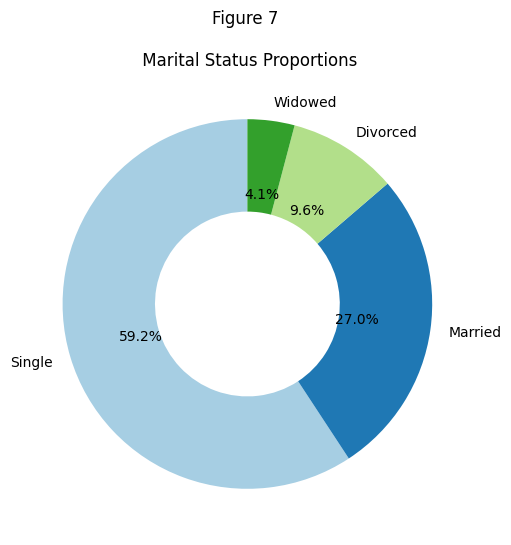

In [48]:
plt.figure(figsize=(6,6))
df['Marital Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90,wedgeprops={'width':0.5}, colors=sns.color_palette('Paired'))
plt.ylabel('')
plt.title('Figure 7 \n\n Marital Status Proportions')
plt.savefig('Marital_Status_Proportions.png', dpi = 300)
plt.show()  # show chart

### Before ploting occupany distribution
we have to define the parameters for living, with First name, househould with less than 2 persons is under utilizes
Household less than 4 users are noraml use, while household greater than 4 is over utilize, this parameters will guide us group and plot our visual

In [49]:
# Count the number of people per house
occupancy = (
    df.groupby(['House Number', 'Street'])['First Name']
      .count()
      .reset_index(name='Occupancy')
)



def classify(n):    #  definind a function to take one argument
    if n <= 2:
        return 'Under-used'      # running if statments to breakdown the logic
    elif n <= 4:
        return 'Normal use'
    else:
        return 'Over-used'
    
occupancy['Usage Level'] = occupancy['Occupancy'].apply(classify)


### Ploting the visuals

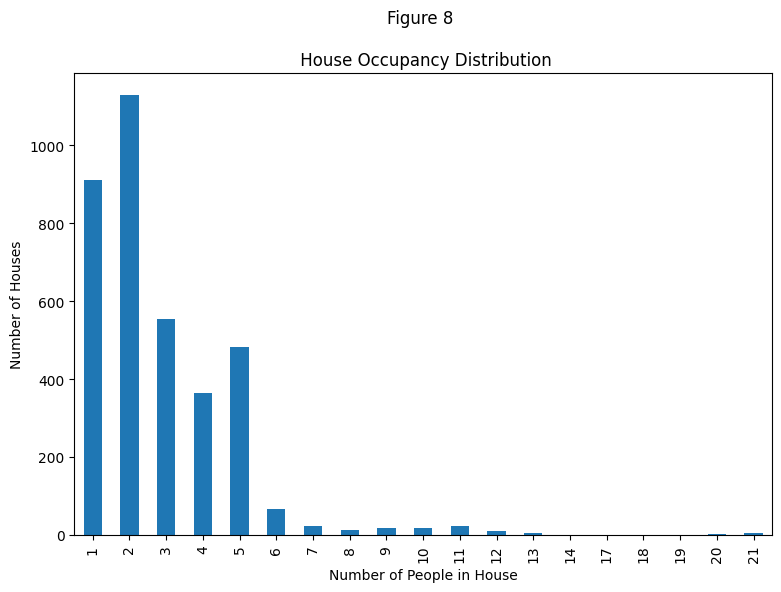

In [50]:

plt.figure(figsize=(9,6))
occupancy['Occupancy'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of People in House')
plt.ylabel('Number of Houses')
plt.title('Figure 8 \n\n House Occupancy Distribution')
plt.savefig('House_Occupancy_Distribution.png', dpi = 300)
plt.show()


In [51]:
df['Occupation_clean'] = df['Occupation'].str.lower().str.strip()

df['Occupation_clean'] = df['Occupation_clean'].replace({
    'university student': 'university student',
    'student': 'student',
    'phd student': 'phd student'
})


uni_students = df['Occupation_clean'].eq('university student').sum()
student_count = df['Occupation_clean'].eq('student').sum()
phd_count = df['Occupation_clean'].eq('phd student').sum()

print(uni_students, student_count, phd_count)


682 2007 11


In [52]:
commuter_keywords = [
    'technician','consultant','psychologist','pharmacist','aid',
    'teacher','operator','underwriter','freight','bookseller'
]

df['Is_Commuter'] = df['Occupation_clean'].apply(
    lambda x: any(word in str(x) for word in commuter_keywords)
)

df['Is_Commuter'].value_counts()


Is_Commuter
False    9806
True      549
Name: count, dtype: int64

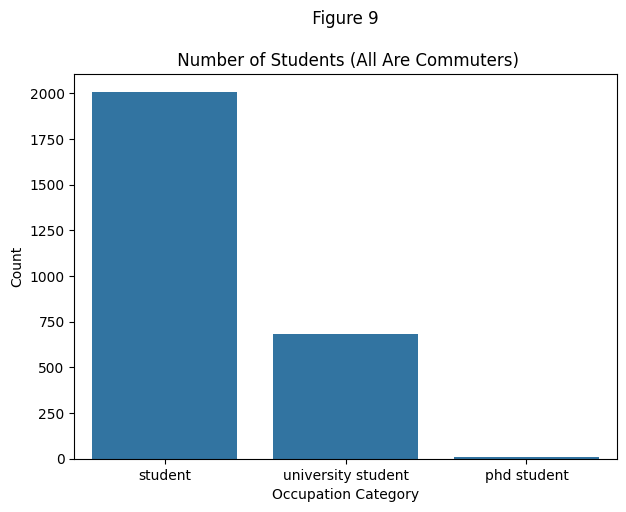

In [53]:


student_counts = df[df['Occupation_clean'].isin(
    ['student', 'university student', 'phd student']
)]['Occupation_clean'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=student_counts.index, y=student_counts.values)
plt.title(" Figure 9 \n\n Number of Students (All Are Commuters)")
plt.xlabel("Occupation Category")
plt.ylabel("Count")
plt.show()


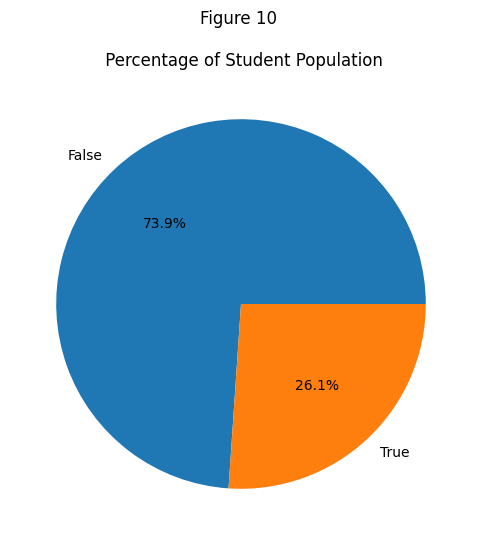

In [54]:
df['Is_Student'] = df['Occupation_clean'].str.contains('student')

df['Is_Student'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    ylabel=''
)
plt.title("Figure 10 \n\n Percentage of Student Population")
plt.show()


In [57]:
len(df.columns)

17

In [56]:
len(df)

10355